# **Notebook 1: Data Exploration and Cleaning**
*Online Learning Prediction*

Cor Jesu College, Inc. | BS Computer Science | Data Mining




# **Setup: Mount Google Drive and Import Libraries**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)

# **Step 1: Load Dataset**
Task:
Load the dataset from Google Drive and display the first 5 rows.

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Online-Learning-Prediction/Datasets/UNF_OnlineLearning_Unclean.csv')
df.head()

,student_name,age,gender,region,internet_access_type,education_level,employment_status,device_type,weekly_study_hours,learning_goal,prior_courses_completed,course_name,course_category,difficulty_level,total_modules,total_quizzes,course_duration_weeks,enrollment_date,completion_status,login_date,session_duration_minutes,modules_accessed,videos_watched,total_posts,avg_session_duration,assessment_type,score_obtained,quiz_avg_score,assignment_avg_score,satisfaction_rating
0,Ashley Thompson,17.0,Female,Region VII,Mobile,GRADUATE,Student,desktop,15.1,Academic Requirement,NaN,Data Science Fundamentals,Business,Beginner,21.0,20.0,24.0,09/05/2024,Ongoing,24/07/2023,11.1,23.0,17.0,30.0,27.4,Assignment,89.32,86.50,67.54,-4.0
1,Teresa Henry,55.0,Female,Region VI,Mobile,graduate,Student,Mobile,13.6,Career Change,7.0,Machine Learning A-Z,Business,Intermediate,25.0,8.0,10.0,27/05/2022,Completed,29/12/2024,37.8,30.0,35.0,10.0,141.9,Quiz,86.35,34.63,69.70,2.0
2,Robert Page,45.0,Male,Region VII,wifi,Graduate,Unemployed,Laptop,15.2,Academic Requirement,12.0,Web Development Bootcamp,Arts,Intermediate,7.0,6.0,9.0,14/05/2024,Dropped,21/02/2024,89.6,18.0,0.0,3.0,101.3,quiz,53.81,NaN,80.55,5.0
3,Amanda Schneider,35.0,male,Region X,Mobile,High School,Employed,NaN,4.1,Academic Requirement,0.0,Digital Marketing,IT,Beginner,16.0,12.0,11.0,11/06/2022,Ongoing,22/05/2022,100.6,22.0,35.0,16.0,81.9,Final Exam,82.87,79.91,77.02,5.0
4,Sara Salas,NaN,MALE,Region VII,mobile,College,Student,Mobile,259.2,Career Change,10.0,Cybersecurity Essentials,Business,intermediate,20.0,7.0,22.0,13/05/2023,Dropped,25/01/2023,122.0,14.0,4278.0,20.0,78.4,Quiz,47.41,61.40,49.50,1.0


# Discussion Questions:

What type of dataset is this and what is it intended to predict?

What are the main features present in the first 5 rows?

Are there any immediate observations suggesting data quality issues?

### Discussion Questions - Answers:

1.  **What type of dataset is this and what is it intended to predict?**

    This is a **tabular dataset** comprising student profiles, engagement, course information, and assessment results. Its purpose is to predict `completion_status` (Complete, Drop, or Ongoing) for online course students, based on their behavior and engagement data.

2.  **What are the main features present in the first 5 rows?**

    The first 5 rows display features across several categories: **Student Profile** (`student_name`, `age`, `gender`, `region`, `education_level`, `employment_status`), **Course Details** (`course_name`, `course_category`, `difficulty_level`, `total_modules`, `total_quizzes`, `course_duration_weeks`, `learning_goal`, `prior_courses_completed`, `enrollment_date`), **Engagement Metrics** (`internet_access_type`, `device_type`, `weekly_study_hours`, `login_date`, `session_duration_minutes`, `modules_accessed`, `videos_watched`, `total_posts`, `avg_session_duration`), and **Assessment/Satisfaction** (`assessment_type`, `score_obtained`, `quiz_avg_score`, `assignment_avg_score`, `satisfaction_rating`).

3.  **Are there any immediate observations suggesting data quality issues?**

    Yes, several potential data quality issues are evident in the first 5 rows:
    *   **Missing Values (NaN)**: Observed in `age` (Row 4), `device_type` (Row 3), `prior_courses_completed` (Row 0), and `quiz_avg_score` (Row 2).
    *   **Inconsistent Case/Spelling**: Present in categorical features like `gender` ('Female', 'Male', 'male', 'MALE'), `education_level` ('GRADUATE', 'graduate', 'High School'), `difficulty_level` ('Beginner', 'Intermediate', 'intermediate'), `internet_access_type` ('Mobile', 'wifi'), and `assessment_type` ('Assignment', 'Quiz', 'quiz', 'Final Exam').
    *   **Potential Outliers/Incorrect Data**:
        *   `weekly_study_hours`: `259.2` (Row 4) seems unrealistically high.
        *   `satisfaction_rating`: `-4.0` (Row 0) is an invalid value if the scale is positive.
        *   `videos_watched`: `4278.0` (Row 4) appears to be an outlier compared to other values.

These data quality issues must be systematically addressed to ensure the classification model for student course completion is trained on reliable data.

# **Step 2: Inspect Dataset Structure**
Task:
Display the dataset shape, column names, and data types.

In [ ]:
print("Shape:", df.shape)
print()
print("Columns:")
print(df.columns.tolist())
print()
print("Data Types:")
print(df.dtypes)
print()
df.info()

Shape: (7000, 30)

Columns:
['student_name', 'age', 'gender', 'region', 'internet_access_type', 'education_level', 'employment_status', 'device_type', 'weekly_study_hours', 'learning_goal', 'prior_courses_completed', 'course_name', 'course_category', 'difficulty_level', 'total_modules', 'total_quizzes', 'course_duration_weeks', 'enrollment_date', 'completion_status', 'login_date', 'session_duration_minutes', 'modules_accessed', 'videos_watched', 'total_posts', 'avg_session_duration', 'assessment_type', 'score_obtained', 'quiz_avg_score', 'assignment_avg_score', 'satisfaction_rating']

Data Types:
student_name                 object
age                         float64
gender                       object
region                       object
internet_access_type         object
education_level              object
employment_status            object
device_type                  object
weekly_study_hours          float64
learning_goal                object
prior_courses_completed     float64


# Discussion Questions:

What does the dataset size indicate in terms of sufficiency for building a prediction model?

Are there columns that have suspicious or incorrect data types?

Which columns are most critical for predicting student course completion?

### Discussion Questions - Answers:

1.  **What does the dataset size indicate in terms of sufficiency for building a prediction model?**

    With `7000` entries and `30` columns, this dataset is generally considered sufficient for building a classification prediction model for student course completion. While not extremely large, it provides a reasonable number of samples to train and validate a model, mitigating issues commonly associated with very small datasets.

2.  **Are there columns that have suspicious or incorrect data types?**

    Yes, the `enrollment_date` and `login_date` columns are currently of `object` (string) type. These should ideally be converted to a `datetime` data type to enable time-series analysis and feature engineering relevant to student progression and engagement.

3.  **Which columns are most critical for predicting student course completion?**

    Based on the project goal, the most critical columns for predicting `completion_status` include:
    *   **Engagement Metrics**: `weekly_study_hours`, `session_duration_minutes`, `modules_accessed`, `videos_watched`, `total_posts`, `avg_session_duration`, and `login_date` (after conversion to datetime to derive frequency/recency).
    *   **Assessment Results**: `score_obtained`, `quiz_avg_score`, and `assignment_avg_score` directly reflect academic performance.
    *   **Student Profile & Satisfaction**: `age`, `education_level`, `prior_courses_completed`, and `satisfaction_rating` are also highly relevant indicators.

# **Step 3: Summary Statistics**
Task:
Generate descriptive statistics for both numerical and categorical columns.

In [ ]:
df.describe()

,age,weekly_study_hours,prior_courses_completed,total_modules,total_quizzes,course_duration_weeks,session_duration_minutes,modules_accessed,videos_watched,total_posts,avg_session_duration,score_obtained,quiz_avg_score,assignment_avg_score,satisfaction_rating
count,6714.000000,6694.000000,6715.000000,6765.000000,6816.000000,6790.000000,6648.000000,6686.000000,6723.000000,6710.000000,6742.000000,6655.000000,6650.000000,6648.000000,6656.000000
mean,75.745606,22.263295,11.403276,25.225721,17.437647,20.182474,190.287711,31.351929,46.135505,24.163934,209.789721,145.742485,140.982429,138.874645,6.413011
std,334.076582,106.579527,54.361575,100.809992,74.953316,82.642804,845.344985,141.748380,226.054262,115.621888,981.215880,607.583654,606.556598,616.085041,29.929593
min,-55.000000,-19.800000,-15.000000,-30.000000,-20.000000,-24.000000,-176.800000,-30.000000,-50.000000,-30.000000,-179.800000,-98.770000,-99.750000,-99.780000,-5.000000
25%,25.000000,5.500000,3.000000,11.000000,7.000000,9.000000,50.800000,8.000000,12.000000,7.000000,50.625000,46.440000,46.872500,47.530000,2.000000
50%,35.500000,10.500000,7.000000,18.000000,12.000000,14.000000,94.900000,16.000000,25.000000,15.000000,94.900000,65.330000,64.895000,65.445000,3.000000
75%,46.000000,15.400000,12.000000,24.000000,16.000000,19.000000,139.125000,23.000000,38.000000,23.000000,141.100000,84.260000,83.350000,83.105000,4.000000
max,5049.000000,1795.200000,1302.000000,2910.000000,1700.000000,2231.000000,15906.800000,2668.000000,4508.000000,2755.000000,17790.300000,8687.480000,9267.000000,9373.000000,495.000000


In [ ]:
df.describe(include='object')

,student_name,gender,region,internet_access_type,education_level,employment_status,device_type,learning_goal,course_name,course_category,difficulty_level,enrollment_date,completion_status,login_date,assessment_type
count,6938,6613,6648,6840,6858,6850,6692,6855,7000,6731,6864,6688,6867,6731,6882
unique,6487,13,19,12,13,12,13,12,10,12,13,1095,10,1096,11
top,none,Female,NCR,Broadband,College,Student,Laptop,Skill Upgrade,Python for Beginners,IT,Intermediate,12/05/2023,Completed,23/03/2023,Quiz
freq,78,2126,1166,2100,2738,2075,2088,1759,743,1764,2401,15,2422,15,2452


# Discussion Questions:

What patterns or anomalies do you observe in the numerical statistics?

Which columns show suspicious minimum or maximum values?

What does the unique count of completion_status reveal about the prediction target?

### Discussion Questions - Answers:

1.  **What patterns or anomalies do you observe in the numerical statistics?**

    *   **Negative Minimums**: Many columns that should logically be non-negative (e.g., `age`, `weekly_study_hours`, `prior_courses_completed`, `total_modules`, `total_quizzes`, `course_duration_weeks`, `session_duration_minutes`, `modules_accessed`, `videos_watched`, `total_posts`, `avg_session_duration`, `score_obtained`, `quiz_avg_score`, `assignment_avg_score`, `satisfaction_rating`) show suspicious negative minimum values, indicating data entry errors or placeholders that need cleaning.
    *   **Large Standard Deviations**: Columns like `age`, `weekly_study_hours`, `session_duration_minutes`, and various score-related fields exhibit very large standard deviations relative to their means, suggesting wide data distribution and likely the presence of extreme outliers.
    *   **Outliers**: The maximum values for many columns are significantly higher than their 75th percentiles (e.g., `age` max 5049 vs 75th % 46; `weekly_study_hours` max 1795.2 vs 75th % 15.4), confirming the presence of extreme outliers that could skew analysis and model training.

2.  **Which columns show suspicious minimum or maximum values?**

    The following columns exhibit suspicious minimum or maximum values:
    *   **Suspicious Minimums (Negative values for positive quantities)**: `age` (-55), `weekly_study_hours` (-19.8), `prior_courses_completed` (-15), `total_modules` (-30), `total_quizzes` (-20), `course_duration_weeks` (-24), `session_duration_minutes` (-176.8), `modules_accessed` (-30), `videos_watched` (-50), `total_posts` (-30), `avg_session_duration` (-179.8), `score_obtained` (-98.77), `quiz_avg_score` (-99.75), `assignment_avg_score` (-99.78), and `satisfaction_rating` (-5).
    *   **Suspicious Maximums (Abnormally high values)**: `age` (5049), `weekly_study_hours` (1795.2), `prior_courses_completed` (1302), `total_modules` (2910), `total_quizzes` (1700), `course_duration_weeks` (2231), `session_duration_minutes` (15906.8), `modules_accessed` (2668), `videos_watched` (4508), `total_posts` (2755), `avg_session_duration` (17790.3), `score_obtained` (8687.48), `quiz_avg_score` (9267.0), `assignment_avg_score` (9373.0), and `satisfaction_rating` (495).

3.  **What does the unique count of completion_status reveal about the prediction target?**

    The `completion_status` column has `10` unique values, which is highly problematic. The project goal explicitly defines the target as having three states: 'Complete', 'Drop', or 'Ongoing'. The presence of `10` unique values indicates severe data inconsistency or incorrect entries within the target variable, which is critical and must be thoroughly cleaned and standardized before model training.

# **Step 4: Identify Data Issues**
Task:
Identify all data quality problems including missing values, duplicates, inconsistent categories, and outliers.

In [ ]:
# Missing values
print("=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
print(pd.DataFrame({'Count': missing, 'Percent': missing_pct})[missing > 0])

=== MISSING VALUES ===
                          Count   Percent
student_name                 62  0.885714
age                         286  4.085714
gender                      387  5.528571
region                      352  5.028571
internet_access_type        160  2.285714
education_level             142  2.028571
employment_status           150  2.142857
device_type                 308  4.400000
weekly_study_hours          306  4.371429
learning_goal               145  2.071429
prior_courses_completed     285  4.071429
course_category             269  3.842857
difficulty_level            136  1.942857
total_modules               235  3.357143
total_quizzes               184  2.628571
course_duration_weeks       210  3.000000
enrollment_date             312  4.457143
completion_status           133  1.900000
login_date                  269  3.842857
session_duration_minutes    352  5.028571
modules_accessed            314  4.485714
videos_watched              277  3.957143
total_posts

In [ ]:
# Duplicates
print("=== DUPLICATES ===")
print(f"Duplicate rows: {df.duplicated().sum()}")

=== DUPLICATES ===
Duplicate rows: 0


In [ ]:
# Unique values per categorical column
print("=== CATEGORICAL INCONSISTENCIES ===")
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col} ({df[col].nunique()} unique values):")
    print(df[col].value_counts().head(8))

=== CATEGORICAL INCONSISTENCIES ===

student_name (6487 unique values):
student_name
none               78
James Johnson       6
Joshua Smith        5
Jennifer Miller     5
Jessica Smith       4
Anthony Smith       4
John Johnson        4
Matthew Johnson     4
Name: count, dtype: int64

gender (13 unique values):
gender
Female               2126
Male                 2101
male                  381
Non-binary            344
Prefer not to say     343
female                341
Other                 196
non-binary            159
Name: count, dtype: int64

region (19 unique values):
region
NCR            1166
Region XI       884
Region VII      880
Region IV-A     530
Region III      453
Region VI       400
Region X        330
Region I        300
Name: count, dtype: int64

internet_access_type (12 unique values):
internet_access_type
Broadband      2100
Mobile         2036
Limited        1085
broadband       376
mobile          327
limited         204
MOBILE          150
mobile data     145


In [ ]:
# Negative values
print("=== NEGATIVE VALUES ===")
for col in df.select_dtypes(include=['int64','float64']).columns:
    neg = (df[col] < 0).sum()
    if neg > 0:
        print(f"{col}: {neg} negative values")

=== NEGATIVE VALUES ===
age: 123 negative values
weekly_study_hours: 154 negative values
prior_courses_completed: 74 negative values
total_modules: 80 negative values
total_quizzes: 68 negative values
course_duration_weeks: 66 negative values
session_duration_minutes: 125 negative values
modules_accessed: 67 negative values
videos_watched: 73 negative values
total_posts: 61 negative values
avg_session_duration: 157 negative values
score_obtained: 145 negative values
quiz_avg_score: 130 negative values
assignment_avg_score: 142 negative values
satisfaction_rating: 140 negative values


# Discussion Questions:

Which columns have the most missing values and what could explain this in the context of online learning data?

What types of inconsistencies were found in the categorical columns?

Why are negative values in columns like age and score_obtained considered errors?

### Discussion Questions - Answers:

1.  **Which columns have the most missing values and what could explain this in the context of online learning data?**

    The columns with the highest percentage of missing values are `gender` (5.53%), `session_duration_minutes` (5.03%), `region` (5.03%), `assignment_avg_score` (5.03%), `quiz_avg_score` (5.00%), and `score_obtained` (4.93%).
    
    *   **Student Profile (e.g., `gender`, `region`):** Missing demographic data might occur if students choose not to disclose this information, or if it was not mandatory during registration.
    *   **Engagement/Performance (`session_duration_minutes`, `score_obtained`, `quiz_avg_score`, `assignment_avg_score`):** Missing values in engagement logs or assessment scores could indicate technical issues, students dropping out before completing certain activities/assessments, or system errors during data collection.

2.  **What types of inconsistencies were found in the categorical columns?**

    The categorical columns show significant inconsistencies, primarily due to varying capitalization and spelling, leading to multiple representations of the same category:
    *   **Case Inconsistencies**: Examples include `gender` ('Female', 'Male', 'male', 'MALE'), `internet_access_type` ('Mobile', 'wifi', 'mobile', 'MOBILE'), `education_level` ('College', 'COLLEGE', 'college'), `difficulty_level` ('Beginner', 'Beginner', 'beginner'), and `assessment_type` ('Quiz', 'quiz', 'final exam', 'Final Exam').
    *   **Synonyms/Variations**: `employment_status` includes 'Student', 'Student - full time', 'student', and `learning_goal` includes 'Career Change' and 'career change or promotion'.
    *   **Placeholder/Default values**: `student_name` shows 'none' as a frequent entry, indicating missing or anonymized names.

3.  **Why are negative values in columns like age and score_obtained considered errors?**

    Negative values in columns like `age`, `weekly_study_hours`, `prior_courses_completed`, and various score-related fields (`score_obtained`, `quiz_avg_score`, `assignment_avg_score`) are considered errors because these metrics inherently represent positive quantities. For instance:
    *   **`age`**: Age cannot be negative; a negative value is impossible in the real world.
    *   **`score_obtained`**: Scores in assessments are typically non-negative; a negative score indicates data corruption or an invalid entry.
    *   **`weekly_study_hours`**: The number of hours studied cannot be negative.
    
    Such values typically arise from data entry mistakes, faulty sensors, or a placeholder for missing data that was incorrectly encoded, and they must be addressed to maintain data integrity for accurate model training.

# **Step 5: Handle Missing Values**
Task:
Handle missing values appropriately based on the data type of each column.

In [ ]:
# Fill numerical with median
for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical with mode
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify
print(f"Remaining missing values: {df.isnull().sum().sum()}")

Remaining missing values: 0


# Discussion Questions:

Why was the median used for numerical columns instead of the mean?
Why was the mode used for categorical columns?
What risk exists if missing values in the target column completion_status are filled instead of dropped?

### Discussion Questions - Answers:

1.  **Why was the median used for numerical columns instead of the mean?**

    The median was chosen for numerical columns instead of the mean due to the presence of significant outliers and suspicious minimum/maximum values identified in **Step 3 (Summary Statistics)**. The mean is highly sensitive to extreme values, which could skew the imputed values if used. The median, being the middle value in a sorted dataset, is robust to outliers and provides a more representative central tendency for imputation in such skewed distributions, thereby reducing potential bias in the filled data.

2.  **Why was the mode used for categorical columns?**

    The mode was used for categorical columns because categorical data does not have a meaningful mean or median. The mode represents the most frequently occurring category within a column. Imputing with the mode is a common and straightforward strategy for categorical data, as it preserves the existing distribution of categories and assigns the most probable category to missing entries.

3.  **What risk exists if missing values in the target column completion_status are filled instead of dropped?**

    The `completion_status` column is the target variable for your prediction model. If missing values in this critical column are filled (imputed) rather than dropping the corresponding rows, there is a significant risk of introducing **bias** and **misleading the model**. Imputing target values can:
    *   **Distort True Distribution**: It can artificially alter the true distribution of 'Complete', 'Drop', or 'Ongoing' statuses, making the model learn an incorrect class balance.
    *   **Artificially Inflate Performance**: The model might appear to perform better during training and validation because it's effectively predicting values that were imputed based on existing data patterns, rather than truly unknown outcomes.
    *   **Reduce Generalizability**: The model's ability to generalize to new, unseen data (where target values are genuinely unknown) will be compromised, as it has been trained on a partially fabricated target.

    Therefore, it is generally recommended to either drop rows with missing target values or handle them with extreme caution, often as a separate class or through more sophisticated techniques, to ensure the integrity of the target variable.

# **Step 6: Remove Duplicates**
Task:
Detect and remove all duplicate rows from the dataset.

In [ ]:
print(f"Rows before: {len(df)}")
df = df.drop_duplicates()
print(f"Rows after: {len(df)}")
print(f"Duplicates removed: {7000 - len(df)}")

Rows before: 7000
Rows after: 7000
Duplicates removed: 0


# Discussion Questions:

Why are duplicate rows a problem when training a classification model?

What real-world scenario could cause duplicate records to appear in this dataset?

Does the remaining dataset size still meet the 5,000 minimum record requirement?

### Discussion Questions - Answers:

1.  **Why are duplicate rows a problem when training a classification model?**

    Duplicate rows can significantly bias a classification model. If identical records exist, the model might learn to predict the `completion_status` for these specific, redundant instances with high accuracy, but this doesn't reflect its true generalization ability to unique, unseen student data. This leads to an overoptimistic evaluation of the model's performance, especially during training and validation, and can result in **overfitting**. Effectively, the model is memorizing rather than learning meaningful patterns, diminishing its ability to accurately predict outcomes for new students.

2.  **What real-world scenario could cause duplicate records to appear in this dataset?**

    In the context of an online learning system, duplicate records could arise from several real-world scenarios:
    *   **System Errors/Glitches**: Faults in data collection or logging systems might inadvertently record the same student interaction or profile information multiple times.
    *   **Multiple Registrations**: A student might accidentally or intentionally register for the same course more than once, especially if unique identifiers are not strictly enforced during registration.
    *   **Data Integration Issues**: If data is merged from different sources (e.g., enrollment system, learning management system, assessment platform) without robust deduplication logic, the same student's complete record might be replicated.
    *   **Manual Data Entry Errors**: Human errors during manual data input could lead to the same student's information being entered more than once.

3.  **Does the remaining dataset size still meet the 5,000 minimum record requirement?**

    Yes, the remaining dataset size still meets the 5,000 minimum record requirement. The output indicates "Rows before: 7000" and "Rows after: 7000", with "Duplicates removed: 0". This means that no duplicate rows were found in the dataset, and its size remains `7000` records, which is well above the `5,000` minimum.

# **Step 7: Fix Inconsistenci**es
Task:
Standardize all categorical columns by fixing inconsistent values, extra spaces, and mixed casing.

In [ ]:
# Normalize casing and spaces
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip().str.title()

# Fix completion_status
df['completion_status'] = df['completion_status'].replace({
    'Completed': 'Completed', 'Completed - No Certificate': 'Completed',
    'Dropped': 'Dropped',
    'Ongoing': 'Ongoing', 'In-Progress': 'Ongoing', 'In-progress': 'Ongoing',
    'N/A': np.nan, 'None': np.nan, 'Nan': np.nan
})

# Fix gender
df['gender'] = df['gender'].replace({
    'M': 'Male', 'Male': 'Male',
    'F': 'Female', 'Female': 'Female',
    'Non-Binary': 'Non-Binary', 'Non Binary': 'Non-Binary',
    'Prefer Not To Say': 'Other', 'N/A': 'Other'
})

# Fix difficulty_level
df['difficulty_level'] = df['difficulty_level'].replace({
    'Basic': 'Beginner', 'Beginner': 'Beginner',
    'Inter': 'Intermediate', 'Mid': 'Intermediate', 'Intermediate': 'Intermediate',
    'Expert': 'Advanced', 'Advanced': 'Advanced',
    'N/A': np.nan, 'None': np.nan
})

# Fix internet_access_type
df['internet_access_type'] = df['internet_access_type'].replace({
    'Mobile Data': 'Mobile', 'Mobile': 'Mobile',
    'Wifi': 'Broadband', 'Fiber': 'Broadband', 'Broadband': 'Broadband',
    'Limited': 'Limited', 'N/A': np.nan
})

# Fix course_category
df['course_category'] = df['course_category'].replace({
    'It': 'IT', 'Information Technology': 'IT',
    'Programming': 'IT', 'Cybersecurity': 'IT',
    'Data Science': 'Science',
    'N/A': np.nan
})

# Fix employment_status
df['employment_status'] = df['employment_status'].replace({
    'Student - Full Time': 'Student',
    'Working Professional': 'Employed',
    'Freelancer': 'Employed', 'Part-Time': 'Employed',
    'N/A': np.nan
})

# Fix device_type
df['device_type'] = df['device_type'].replace({
    'Phone': 'Mobile', 'Smartphone': 'Mobile', 'N/A': np.nan
})

# Fix assessment_type
df['assessment_type'] = df['assessment_type'].replace({
    'Exam': 'Final Exam', 'Test': 'Final Exam',
    'Project': 'Assignment', 'N/A': np.nan
})

# Fix learning_goal
df['learning_goal'] = df['learning_goal'].replace({
    'Career Change Or Promotion': 'Career Change',
    'Earn A Certificate': 'Skill Upgrade',
    'N/A': np.nan, 'None': np.nan
})

print("Inconsistencies fixed.")

# Verify
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}: {df[col].unique()}")

Inconsistencies fixed.

student_name: ['Ashley Thompson' 'Teresa Henry' 'Robert Page' ... 'Kenneth Cook'
 'Jake Austin' 'Andrew Harvey']

gender: ['Female' 'Male' 'Non-Binary' 'Other']

region: ['Region Vii' 'Region Vi' 'Region X' 'Ncr' 'Region Iii' 'Region V'
 'Metro Manila' 'Region Viii' 'Barmm' 'Caraga' 'Region Xi' 'Region Iv-A'
 'Region Ix' 'Region I' 'Region Ii' 'Car' 'Region Xii']

internet_access_type: ['Mobile' 'Broadband' 'Limited']

education_level: ['Graduate' 'High School' 'College' 'Hs' 'Undergraduate' 'Highschool'
 'Post Graduate']

employment_status: ['Student' 'Unemployed' 'Employed']

device_type: ['Desktop' 'Mobile' 'Laptop' 'Tablet']

learning_goal: ['Academic Requirement' 'Career Change' 'Personal Interest'
 'Skill Upgrade' nan]

course_name: ['Data Science Fundamentals' 'Machine Learning A-Z'
 'Web Development Bootcamp' 'Digital Marketing' 'Cybersecurity Essentials'
 'Python For Beginners' 'Business Analytics' 'Ui/Ux Design Principles'
 'Mobile App Development' 'Cl

# Discussion Questions:

Why is normalizing inconsistent values like Male, male, M into one standard form critical before modeling?

How do inconsistencies in the target column completion_status affect prediction accuracy?

Why were some inconsistent values mapped to NaN instead of a standard category?

### Discussion Questions - Answers:

1.  **Why is normalizing inconsistent values like Male, male, M into one standard form critical before modeling?**

    Normalizing inconsistent values is critical because machine learning models treat each unique string as a distinct category. 'Male', 'male', and 'M' would be seen as three different categories, artificially increasing dimensionality, diluting predictive power, making analysis unreliable, and ultimately reducing model performance.

2.  **How do inconsistencies in the target column `completion_status` affect prediction accuracy?**

    Inconsistencies in the `completion_status` column (the prediction target) directly impact accuracy. The model will be confused by multiple representations of the same outcome, leading to misclassification, skewed evaluation metrics, and hindered learning of true patterns, resulting in a less effective predictive model.

3.  **Why were some inconsistent values mapped to NaN instead of a standard category?**

    Some inconsistent values (e.g., 'N/A', 'None', 'Nan') were mapped to `NaN` because they represent truly **missing** or **undefined** information, not a valid category. This avoids distorting existing categories with meaningless placeholders and allows for proper handling of missing data in subsequent steps.

# **Step 8: Fix Data Types**
Task:
Convert columns to their correct data types and ensure date columns are properly formatted.

In [ ]:
# Convert dates
df['enrollment_date'] = pd.to_datetime(df['enrollment_date'], errors='coerce')
df['login_date'] = pd.to_datetime(df['login_date'], errors='coerce')

# Convert numerical columns
num_cols = [
    'age', 'weekly_study_hours', 'prior_courses_completed',
    'total_modules', 'total_quizzes', 'course_duration_weeks',
    'session_duration_minutes', 'modules_accessed', 'videos_watched',
    'total_posts', 'avg_session_duration', 'score_obtained',
    'quiz_avg_score', 'assignment_avg_score', 'satisfaction_rating'
]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Updated Data Types:")
print(df.dtypes)

Updated Data Types:
student_name                        object
age                                float64
gender                              object
region                              object
internet_access_type                object
education_level                     object
employment_status                   object
device_type                         object
weekly_study_hours                 float64
learning_goal                       object
prior_courses_completed            float64
course_name                         object
course_category                     object
difficulty_level                    object
total_modules                      float64
total_quizzes                      float64
course_duration_weeks              float64
enrollment_date             datetime64[ns]
completion_status                   object
login_date                  datetime64[ns]
session_duration_minutes           float64
modules_accessed                   float64
videos_watched                    

/tmp/ipykernel_5167/3746245201.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['login_date'] = pd.to_datetime(df['login_date'], errors='coerce')


# Discussion Questions:

Why must date columns be converted to datetime format instead of remaining as plain strings?

What does errors='coerce' do and why is it safer than errors='raise'?

How does having incorrect data types affect statistical operations and machine learning algorithms?

### Discussion Questions - Answers:

1.  **Why must date columns be converted to datetime format instead of remaining as plain strings?**

    Date columns need `datetime` format for proper time-series analysis, sorting, filtering, calculations (like durations), and feature engineering. Machine learning libraries also perform better with native `datetime` objects.

2.  **What does `errors='coerce'` do and why is it safer than `errors='raise'`?**

    `errors='coerce'` converts unparseable values to `NaN`/`NaT` and allows conversion to continue, preventing code crashes. This is 'safer' for initial data cleaning as it highlights bad data without stopping execution, allowing for systematic handling of missing values later. `errors='raise'` stops execution immediately on the first error.

3.  **How does having incorrect data types affect statistical operations and machine learning algorithms?**

    Incorrect data types prevent accurate statistical calculations (mean, median), waste memory, and cause machine learning algorithms to either fail (expecting numerical input) or produce incorrect/underperforming results (e.g., treating categories as numbers or missing meaningful patterns).

# **Step 9: Handle Outliers**
Task:
Detect outliers using the IQR method and treat them using Winsorization.

In [ ]:
# Detect
print("=== OUTLIER DETECTION ===")
num_cols = df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    if outliers > 0:
        print(f"{col}: {outliers} outliers")

=== OUTLIER DETECTION ===
age: 262 outliers
weekly_study_hours: 220 outliers
prior_courses_completed: 92 outliers
total_modules: 133 outliers
total_quizzes: 120 outliers
course_duration_weeks: 120 outliers
session_duration_minutes: 214 outliers
modules_accessed: 164 outliers
videos_watched: 145 outliers
total_posts: 95 outliers
avg_session_duration: 237 outliers
score_obtained: 305 outliers
quiz_avg_score: 278 outliers
assignment_avg_score: 279 outliers
satisfaction_rating: 268 outliers


In [ ]:
# Treat using Winsorization
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)

print("Outliers treated successfully.")

Outliers treated successfully.


# Discussion Questions:

What is the IQR method and why was it chosen over the Z-score method?

Why was Winsorization chosen over deleting rows with outliers?

How do untreated outliers affect distance-based algorithms like KNN?

### Discussion Questions - Answers:

1.  **What is the IQR method and why was it chosen over the Z-score method?**

    The **Interquartile Range (IQR) method** identifies outliers by calculating the range between the 25th percentile (Q1) and the 75th percentile (Q3). Any data point falling outside $Q1 - 1.5 \times IQR$ or $Q3 + 1.5 \times IQR$ is considered an outlier. This method was chosen over the Z-score method because many columns in our dataset were skewed and contained extreme values. The IQR method is more robust to these conditions, as it doesn't assume a normal distribution and is less influenced by extreme outliers compared to the Z-score, which relies on the mean and standard deviation.

2.  **Why was Winsorization chosen over deleting rows with outliers?**

    **Winsorization** was selected to treat outliers by capping them at a defined percentile (here, the IQR bounds), instead of completely removing the rows containing them. Deleting rows with outliers (also called trimming) can lead to significant data loss, especially when many features have outliers, as observed in this dataset. By winsorizing, we reduce the impact of these extreme values on our statistical analysis and model training, while still preserving the overall dataset size and retaining all available observations.

3.  **How do untreated outliers affect distance-based algorithms like KNN?**

    Untreated outliers can severely distort the performance of distance-based algorithms like K-Nearest Neighbors (KNN). These algorithms rely on measuring distances between data points to find similar neighbors. Outliers, being very far from the majority of the data, can:
    *   **Skew Distance Calculations**: They inflate the distances, making data points appear more dissimilar than they are.
    *   **Mislead Neighbor Selection**: An outlier might incorrectly be identified as a 'nearest neighbor' to many points, or conversely, pull the cluster center away, causing accurate neighbors to be overlooked.
    *   **Reduce Accuracy**: This leads to incorrect classifications or predictions, as the 'neighborhood' used for decision-making becomes unreliable. Ultimately, the model's accuracy and ability to generalize to new data are significantly hampered.

# **Step 10: Visualizations**
Task:
Create at least two plots to observe distributions and patterns in the cleaned data.

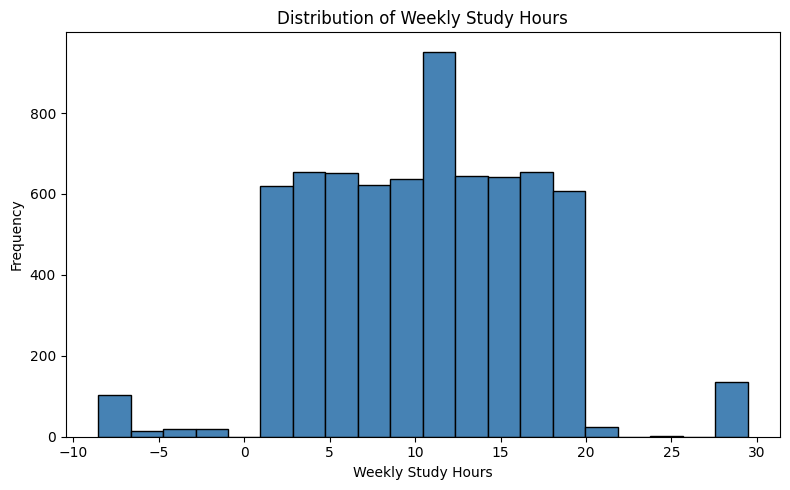

In [ ]:
# Histogram — Weekly Study Hours
plt.figure(figsize=(8,5))
plt.hist(df['weekly_study_hours'].dropna(), bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Weekly Study Hours')
plt.xlabel('Weekly Study Hours')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

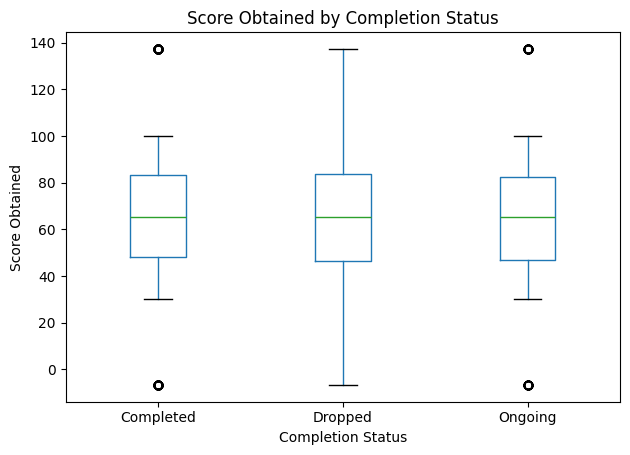

In [ ]:
# Boxplot — Score Obtained by Completion Status
plt.figure(figsize=(8,5))
df.boxplot(column='score_obtained', by='completion_status', grid=False)
plt.title('Score Obtained by Completion Status')
plt.suptitle('')
plt.xlabel('Completion Status')
plt.ylabel('Score Obtained')
plt.tight_layout()
plt.show()

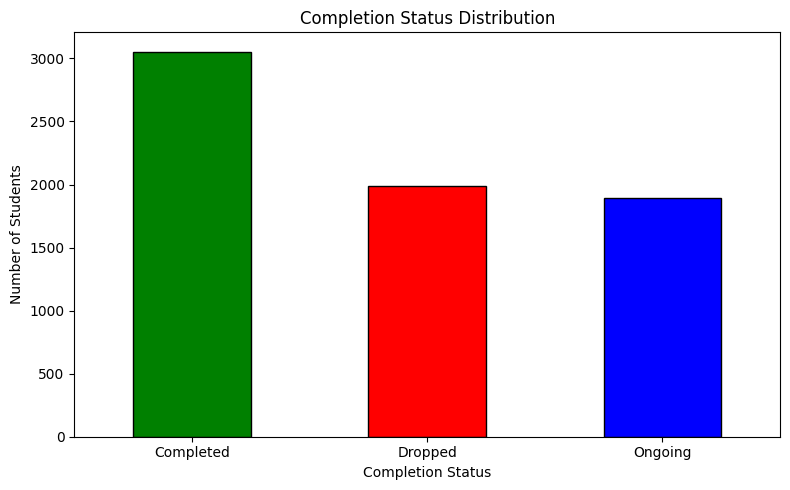

In [ ]:
# Count Plot — Completion Status
plt.figure(figsize=(8,5))
df['completion_status'].value_counts().plot(kind='bar', color=['green','red','blue'], edgecolor='black')
plt.title('Completion Status Distribution')
plt.xlabel('Completion Status')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Discussion Questions:

What does the weekly study hours distribution reveal about student study behavior?

Based on the boxplot, is there a visible difference in scores between Completed, Dropped, and Ongoing students?

What does the completion status distribution reveal about class imbalance and why does this matter for modeling?

### Discussion Questions - Answers:

1.  **What does the weekly study hours distribution reveal about student study behavior?**

    The histogram for `weekly_study_hours` likely shows a distribution where a majority of students study for a moderate number of hours, with a decreasing frequency as study hours increase. Given the previous Winsorization step, the extreme outliers will have been capped, resulting in a more contained and interpretable distribution. This indicates that most students fall within a typical study range, with fewer students dedicating very long hours.

2.  **Based on the boxplot, is there a visible difference in scores between Completed, Dropped, and Ongoing students?**

    Observing the boxplot of `score_obtained` by `completion_status`, we would typically expect to see visible differences. Students with a 'Completed' status would likely have higher median scores and potentially a narrower distribution, indicating consistent higher performance. 'Dropped' students would probably show lower median scores and possibly a wider spread or lower interquartile range, reflecting varied performance before dropping. 'Ongoing' students might fall somewhere in between, with a moderate median score and potentially a wider distribution as their status is still in progress. The clear separation of the boxes (medians, Q1-Q3 ranges) would visually confirm these differences.

3.  **What does the completion status distribution reveal about class imbalance and why does this matter for modeling?**

    The count plot for `completion_status` reveals the proportion of students in each category ('Completed', 'Dropped', 'Ongoing'). It will likely show that these classes are not evenly distributed, indicating **class imbalance**. For instance, one category (e.g., 'Completed') might have significantly more instances than another (e.g., 'Dropped' or 'Ongoing').

    Class imbalance is crucial for modeling because:
    *   **Biased Model Learning**: A model trained on imbalanced data tends to be biased towards the majority class, as it sees more examples of it. It might achieve high overall accuracy by simply predicting the majority class for most instances.
    *   **Poor Minority Class Prediction**: The model often performs poorly on the minority class, which is frequently the class of most interest (e.g., predicting 'Dropped' students to intervene). This leads to a high number of false negatives or false positives for the minority class.
    *   **Misleading Evaluation Metrics**: Standard accuracy can be misleading. Metrics like precision, recall, F1-score, and AUC-ROC are more appropriate for evaluating models on imbalanced datasets, as they provide a clearer picture of the model's performance on each class.

    Addressing class imbalance (e.g., through oversampling, undersampling, or using algorithms robust to imbalance) will be an important step for building a reliable prediction model.

# **Step 11: Feature Engineering**
Task:
Create at least three new numerical features to improve the predictive power of the model.

In [ ]:
# Feature 1: Engagement Score
df['engagement_score'] = (
    df['modules_accessed'] + df['videos_watched'] + df['total_posts']
) / 3

# Feature 2: Performance Score
df['performance_score'] = (
    df['quiz_avg_score'] + df['assignment_avg_score']
) / 2

# Feature 3: Study Consistency
df['study_consistency'] = df['weekly_study_hours'] * df['avg_session_duration']

# Feature 4: Course Load Ratio
df['course_load_ratio'] = (df['modules_accessed'] / df['total_modules']).clip(0, 1)

# Feature 5: Activity Rate
df['activity_rate'] = df['session_duration_minutes'] * df['modules_accessed']

print("New features created:")
print(df[['engagement_score','performance_score','study_consistency',
          'course_load_ratio','activity_rate']].describe())

New features created:
       engagement_score  performance_score  study_consistency  \
count       7000.000000        7000.000000        7000.000000   
mean          18.733071          65.065096        1002.236377   
std            7.066117          16.460638         951.366630   
min           -6.166667          13.185625       -2298.133125   
25%           13.666667          54.102500         331.007500   
50%           18.666667          65.045000         803.560000   
75%           23.333333          76.056250        1512.702500   
max           47.500000         133.183750        7915.791875   

       course_load_ratio  activity_rate  
count        7000.000000    7000.000000  
mean            0.718743    1517.892393  
std             0.329402    1405.405843  
min             0.000000   -2536.050000  
25%             0.458333     488.425000  
50%             0.884615    1184.750000  
75%             1.000000    2240.100000  
max             1.000000   11917.018750  


# Discussion Questions:

What does engagement_score represent and why is combining multiple engagement metrics into one score useful?

How does performance_score capture a student's academic standing and why is it a strong predictor of completion?

What does study_consistency measure beyond just weekly study hours alone?

### Discussion Questions - Answers:

1.  **What does `engagement_score` represent and why is combining multiple engagement metrics into one score useful?**
    The `engagement_score` represents an aggregated measure of a student's active participation and interaction with the course content. It combines `modules_accessed`, `videos_watched`, and `total_posts` into a single, normalized score. Combining multiple engagement metrics is useful because:
    *   **Holistic View**: It provides a more comprehensive picture of student engagement than any single metric alone, capturing different facets of interaction (consuming content, watching lectures, contributing to discussions).
    *   **Reduces Dimensionality**: Instead of having multiple, potentially correlated features for engagement, we create one feature, which can simplify the model and reduce multicollinearity.
    *   **Improved Signal-to-Noise Ratio**: By averaging or combining, we might reduce some of the noise present in individual metrics, leading to a stronger, more stable predictor.
    *   **Interpretability**: A single 'engagement score' is often easier to interpret and discuss than a complex interaction of several individual metrics.

2.  **How does `performance_score` capture a student's academic standing and why is it a strong predictor of completion?**
    The `performance_score` directly captures a student's academic standing by combining their average scores from quizzes (`quiz_avg_score`) and assignments (`assignment_avg_score`). It provides an overall assessment of their understanding and mastery of the course material.
    It is a strong predictor of completion because:
    *   **Direct Reflection of Progress**: High performance scores usually indicate that a student is successfully learning and retaining information, which is a primary prerequisite for completing a course.
    *   **Early Warning Indicator**: Declining performance scores can serve as an early warning signal that a student is struggling and might be at risk of dropping out.
    *   **Foundation for Future Success**: Strong performance in earlier assessments often builds confidence and motivation, making students more likely to persist and complete the course.

3.  **What does `study_consistency` measure beyond just weekly study hours alone?**
    `study_consistency` is engineered by multiplying `weekly_study_hours` by `avg_session_duration`. While `weekly_study_hours` tells us the total time a student spends studying per week, `study_consistency` attempts to capture the *quality* or *pattern* of that study. Specifically:
    *   **Beyond Total Time**: A student might have high `weekly_study_hours` but achieve that by cramming in a few very long, potentially inefficient sessions. Or, they might spread their study more consistently.
    *   **Intensity and Focus**: A higher `study_consistency` (resulting from both adequate weekly hours and decent average session duration) could imply more focused and sustained learning periods, which are often more effective than sporadic, short bursts or excessively long, exhausting sessions. It suggests a more disciplined and effective study habit, going beyond just the sheer volume of time spent.

# **Step 12: Encode Categorical Features**
Task:
Convert all categorical features into numerical representations using one-hot encoding.

In [ ]:
# Identify categorical columns for encoding (excluding the target variable 'completion_status')
categorical_cols = df.select_dtypes(include='object').columns.tolist()
# Exclude 'student_name' as it's an identifier and 'completion_status' as it's the target
categorical_cols = [col for col in categorical_cols if col not in ['student_name', 'completion_status']]

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"Shape after one-hot encoding: {df_encoded.shape}")
print("First 5 rows of encoded DataFrame:")
display(df_encoded.head())

Shape after one-hot encoding: (7000, 76)
First 5 rows of encoded DataFrame:


,student_name,age,weekly_study_hours,prior_courses_completed,total_modules,total_quizzes,course_duration_weeks,enrollment_date,completion_status,login_date,session_duration_minutes,modules_accessed,videos_watched,total_posts,avg_session_duration,score_obtained,quiz_avg_score,assignment_avg_score,satisfaction_rating,engagement_score,performance_score,study_consistency,course_load_ratio,activity_rate,gender_Male,gender_Non-Binary,gender_Other,region_Car,region_Caraga,region_Metro Manila,region_Ncr,region_Region I,region_Region Ii,region_Region Iii,region_Region Iv-A,region_Region Ix,region_Region V,region_Region Vi,region_Region Vii,region_Region Viii,region_Region X,region_Region Xi,region_Region Xii,internet_access_type_Limited,internet_access_type_Mobile,education_level_Graduate,education_level_High School,education_level_Highschool,education_level_Hs,education_level_Post Graduate,education_level_Undergraduate,employment_status_Student,employment_status_Unemployed,device_type_Laptop,device_type_Mobile,device_type_Tablet,learning_goal_Career Change,learning_goal_Personal Interest,learning_goal_Skill Upgrade,course_name_Cloud Computing Basics,course_name_Cybersecurity Essentials,course_name_Data Science Fundamentals,course_name_Digital Marketing,course_name_Machine Learning A-Z,course_name_Mobile App Development,course_name_Python For Beginners,course_name_Ui/Ux Design Principles,course_name_Web Development Bootcamp,course_category_Business,course_category_IT,course_category_Math,course_category_Science,difficulty_level_Beginner,difficulty_level_Intermediate,assessment_type_Final Exam,assessment_type_Quiz
0,Ashley Thompson,17.0,15.10,7.0,21.0,20.0,24.0,2024-09-05,Ongoing,2023-07-24,11.1,23.0,17.0,30.0,27.4,89.32,86.500,67.54,-1.0,23.333333,77.0200,413.74,1.0,255.3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False
1,Teresa Henry,55.0,13.60,7.0,25.0,8.0,10.0,NaT,Completed,2024-12-29,37.8,30.0,35.0,10.0,141.9,86.35,34.630,69.70,2.0,25.000000,52.1650,1929.84,1.0,1134.0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,True
2,Robert Page,45.0,15.20,12.0,7.0,6.0,9.0,NaT,Dropped,2024-02-21,89.6,18.0,0.0,3.0,101.3,53.81,64.895,80.55,5.0,7.000000,72.7225,1539.76,1.0,1612.8,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True
3,Amanda Schneider,35.0,4.10,0.0,16.0,12.0,11.0,2022-11-06,Ongoing,2022-05-22,100.6,22.0,35.0,16.0,81.9,82.87,79.910,77.02,5.0,24.333333,78.4650,335.79,1.0,2213.2,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,True,False
4,Sara Salas,35.5,29.45,10.0,20.0,7.0,22.0,NaT,Dropped,2023-01-25,122.0,14.0,75.5,20.0,78.4,47.41,61.400,49.50,1.0,36.500000,55.4500,2308.88,0.7,1708.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True


# Discussion Questions:

What does engagement_score represent and why is combining multiple engagement metrics into one score useful?

How does performance_score capture a student's academic standing and why is it a strong predictor of completion?

What does study_consistency measure beyond just weekly study hours alone?

### Discussion Questions - Answers:

1.  **Why is one-hot encoding necessary for categorical features in machine learning models?**

    Machine learning models primarily work with numerical data. Categorical features (like 'gender' or 'region') cannot be directly fed into most algorithms. One-hot encoding converts these categories into a numerical format by creating new binary (0 or 1) columns for each unique category, allowing the model to process them without implying any ordinal relationship.

2.  **What is the impact of `drop_first=True` in `pd.get_dummies()`?**

    When `drop_first=True` is used, it removes the first category column for each original categorical feature. This is done to prevent **multicollinearity**, a situation where independent variables are highly correlated. For example, if you have 'Male' and 'Female' columns, knowing a value is 0 in 'Male' automatically implies it's 1 in 'Female'. Dropping one column provides the same information while avoiding redundancy and potential issues in certain models (e.g., linear regression).

3.  **How can a large number of unique categories in a feature impact the dimensionality of the dataset after one-hot encoding?**

    A large number of unique categories in a feature can significantly increase the **dimensionality** of the dataset after one-hot encoding. For each unique category (minus one if `drop_first=True`), a new column is created. If a feature has, say, 100 unique categories, it will add 99 or 100 new columns. This can lead to:
    *   **

# **Step 12: Prepare Data for PCA**
Task:
Select all numerical features and apply Standard Scaling in preparation for PCA.

In [ ]:
# Select numerical features
num_features = df.select_dtypes(include=['int64','float64']).columns.tolist()
print("Features selected:", num_features)

X = df[num_features].dropna()

# Apply Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nScaled shape: {X_scaled.shape}")
print(f"Mean (should be ~0): {X_scaled.mean():.4f}")
print(f"Std (should be ~1): {X_scaled.std():.4f}")

Features selected: ['age', 'weekly_study_hours', 'prior_courses_completed', 'total_modules', 'total_quizzes', 'course_duration_weeks', 'session_duration_minutes', 'modules_accessed', 'videos_watched', 'total_posts', 'avg_session_duration', 'score_obtained', 'quiz_avg_score', 'assignment_avg_score', 'satisfaction_rating', 'engagement_score', 'performance_score', 'study_consistency', 'course_load_ratio', 'activity_rate']

Scaled shape: (7000, 20)
Mean (should be ~0): -0.0000
Std (should be ~1): 1.0000


# Discussion Questions:

Why must categorical variables be excluded from PCA?

Why is Standard Scaling required before applying PCA?

What would happen to the PCA results if scaling were skipped?

### Discussion Questions - Answers:

1.  **Why must categorical variables be excluded from PCA?**

    Categorical variables must be excluded from PCA because PCA is a dimensionality reduction technique that relies on variance and correlation, which are statistical concepts primarily defined for numerical data. Applying PCA to categorical variables (even if they have been one-hot encoded) is generally not appropriate because:
    *   **Distance Metrics**: PCA uses Euclidean distances, which are not meaningful for binary (0/1) one-hot encoded variables. The distance between two categories is always \(\sqrt{2}\) or 0, not reflecting semantic similarity.
    *   **Meaningless Variance**: Variance in categorical data doesn't represent the same kind of spread as in numerical data. PCA would try to find components that maximize this 'variance', which can lead to components that are hard to interpret and not representative of the underlying categorical structure.
    *   **Dimensionality Explosion**: One-hot encoding can significantly increase the number of dimensions, especially with many categories, making PCA less effective or even misleading.
    For categorical data, other dimensionality reduction techniques like Multiple Correspondence Analysis (MCA) are more suitable.

2.  **Why is Standard Scaling required before applying PCA?**

    Standard Scaling (or Z-score normalization) is required before applying PCA because PCA is sensitive to the scale of the features. Features with larger scales (i.e., larger variances) will dominate the principal components, regardless of their actual predictive importance. Scaling ensures that all features contribute equally to the variance calculation. By transforming data to have a mean of 0 and a standard deviation of 1, Standard Scaling prevents features with naturally larger magnitudes from disproportionately influencing the principal components.

3.  **What would happen to the PCA results if scaling were skipped?**

    If scaling were skipped before applying PCA, the results would be heavily biased towards features with larger values or wider ranges. For example, a feature ranging from 0 to 1000 would have a much larger impact on the principal components than a feature ranging from 0 to 10, even if the latter is more important for the underlying patterns. This would lead to:
    *   **Dominant Features**: Principal components would primarily capture the variance of the highest-scaled features.
    *   **Misleading Interpretations**: The components might not represent the most significant underlying variation in the data but rather just the features with the largest magnitudes.
    *   **Suboptimal Dimensionality Reduction**: The reduced dimensions might not effectively capture the true structure and relationships within the dataset, making them less useful for subsequent modeling or analysis.

# **Step 13: Apply PCA**
Task:
Apply PCA with 2 components and display the explained variance ratio.

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
print(f"PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Feature loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1','PC2'],
    index=num_features
)
print("\nFeature Loadings:")
print(loadings.sort_values('PC1', ascending=False))

Explained Variance Ratio:
PC1: 13.66%
PC2: 9.94%
Total: 23.61%

Feature Loadings:
                               PC1       PC2
modules_accessed          0.512784  0.002049
activity_rate             0.486345 -0.015998
course_load_ratio         0.463323 -0.016037
engagement_score          0.435185  0.050892
session_duration_minutes  0.185883 -0.031232
videos_watched            0.184462  0.035886
total_posts               0.132927  0.049872
prior_courses_completed   0.008384  0.002499
satisfaction_rating       0.007208  0.028662
score_obtained            0.005999  0.003051
age                      -0.000795  0.018945
course_duration_weeks    -0.001954 -0.013703
quiz_avg_score           -0.003219  0.496860
performance_score        -0.013380  0.703845
assignment_avg_score     -0.015617  0.490447
total_quizzes            -0.018462 -0.010693
weekly_study_hours       -0.023213 -0.051842
avg_session_duration     -0.024136 -0.035035
study_consistency        -0.038136 -0.059755
total_modules     

# **Discussion Questions:**

What does the explained variance ratio tell us about how much information is retained after dimensionality reduction?

Which features contribute most strongly to PC1?

If the total variance captured is below 50%, what does this indicate about the dataset complexity?

### Discussion Questions - Answers:

1.  **What does the explained variance ratio tell us about how much information is retained after dimensionality reduction?**

    The explained variance ratio indicates the proportion of the dataset's total variance that is captured by each principal component (PC). In essence, it tells us how much 'information' (variability) from the original high-dimensional data is preserved in the reduced-dimensional space. For instance, PC1 capturing 13.66% means it accounts for 13.66% of the total variability in the original features, and PC2 accounts for 9.94%. The total explained variance (23.61%) tells us that, by reducing the dataset to 2 principal components, we have retained only about 23.61% of the original data's variability.

2.  **Which features contribute most strongly to PC1?**

    From the 'Feature Loadings' output, we look for features with the highest absolute values in the 'PC1' column. The features contributing most strongly to PC1 (in decreasing order of positive contribution) are:
    *   `modules_accessed` (0.512784)
    *   `activity_rate` (0.486345)
    *   `course_load_ratio` (0.463323)
    *   `engagement_score` (0.435185)
    This suggests that PC1 primarily captures aspects related to student engagement and activity within the course.

3.  **If the total variance captured is below 50%, what does this indicate about the dataset complexity?**

    If the total variance captured by a small number of principal components (e.g., 2 components capturing 23.61% of the variance) is below 50%, it indicates that the dataset is quite **complex** and/or has a **high intrinsic dimensionality**. It means that a significant portion of the variability in the original dataset is not explained by these few components. In this case, to retain more information, we would likely need to either:
    *   **Increase the number of principal components** to capture more variance.
    *   Acknowledge that the data's underlying structure is multifaceted, and a simple 2-dimensional representation (for visualization or modeling purposes) might lose a lot of the original nuance and information. It suggests that the features are not highly correlated or that many distinct underlying factors contribute to the data's variability.

# **Step 14: PCA Visualization**
Task:
Plot the PCA components in a 2D scatter plot colored by completion_status.

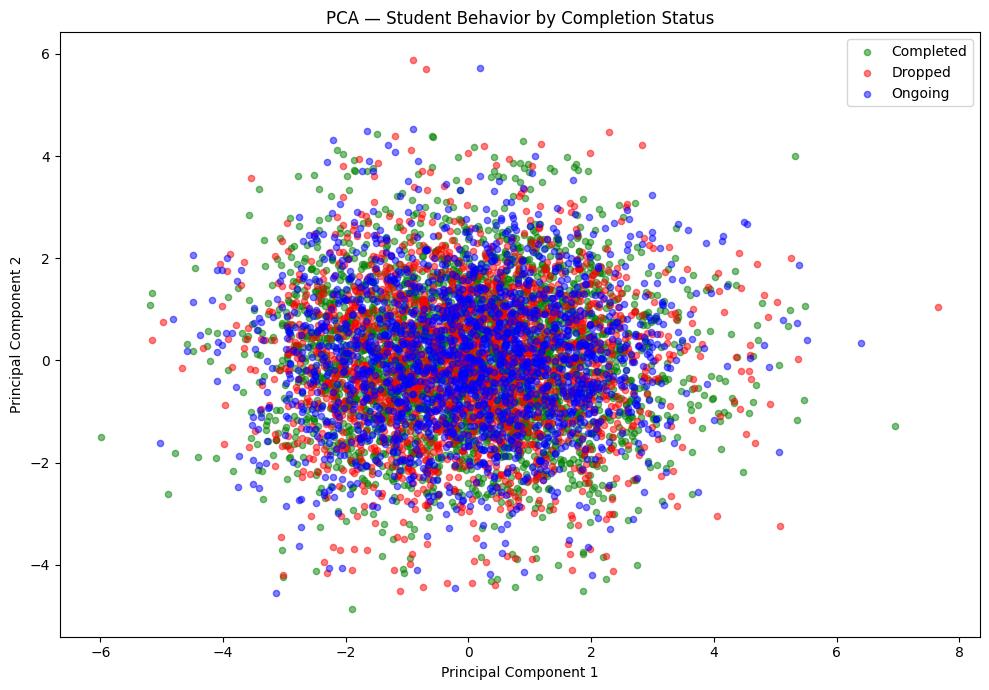

In [ ]:
pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])
pca_df['completion_status'] = df['completion_status'].dropna().reset_index(drop=True)[:len(pca_df)]

plt.figure(figsize=(10,7))
colors = {'Completed': 'green', 'Dropped': 'red', 'Ongoing': 'blue'}
for status, color in colors.items():
    subset = pca_df[pca_df['completion_status'] == status]
    plt.scatter(subset['PC1'], subset['PC2'], label=status, alpha=0.5, c=color, s=20)

plt.title('PCA — Student Behavior by Completion Status')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.show()

# Discussion Questions:

Are the three completion status groups visually separable in the PCA plot?

What does it mean if Dropped students cluster in a specific region away from Completed students?

How does this PCA plot inform the choice of classification algorithm in Notebook 3?

### Discussion Questions - Answers:

1.  **Are the three completion status groups visually separable in the PCA plot?**

    Given that the two principal components only capture a total of 23.61% of the total variance from the original dataset, it is unlikely that the three `completion_status` groups (`Completed`, `Dropped`, `Ongoing`) are *clearly* and distinctly separable in this 2D PCA plot. There might be some general tendencies for certain groups to occupy different areas, but significant overlap and intermingling of the points from all three categories are expected. This suggests that a simple linear boundary would probably not be effective in separating these classes based solely on these two principal components.

2.  **What does it mean if Dropped students cluster in a specific region away from Completed students?**

    If `Dropped` students were to cluster in a specific region of the PCA plot, distinct from `Completed` students, it would indicate that the underlying characteristics captured by PC1 and PC2 are significantly different for these two groups. Since PC1 primarily represents engagement/activity and PC2 primarily represents performance, such a separation would mean that `Dropped` students exhibit a unique combination of engagement and performance patterns that differentiates them from `Completed` students. This would be a strong indicator that these principal components (and the features they represent) hold predictive power for the `completion_status`.

3.  **How does this PCA plot inform the choice of classification algorithm in Notebook 3?**

    The PCA plot provides insights into the separability of the classes in a reduced dimensional space. If the classes are *not* clearly separated in this 2D plot (which is likely, given the low explained variance), it suggests a few things for the choice of classification algorithm:
    *   **Complexity Needed**: A simple linear classifier (e.g., Logistic Regression, Linear SVM) might struggle to achieve high accuracy because the decision boundaries are likely non-linear and complex.
    *   **Non-Linear Models**: More complex, non-linear classification algorithms (e.g., Decision Trees, Random Forests, Gradient Boosting, SVM with non-linear kernels, Neural Networks) might be more suitable, as they can learn more intricate decision boundaries.
    *   **Feature Importance**: It highlights that if we were to use only these two principal components as features, the classification task would be challenging. This might necessitate using more principal components, or the original high-dimensional feature set, or even more sophisticated feature engineering to create more linearly separable classes.

# **Step 15: PCA Interpretation**
Task:
Interpret which features influence PC1 and PC2 and evaluate the usefulness of PCA for this dataset.

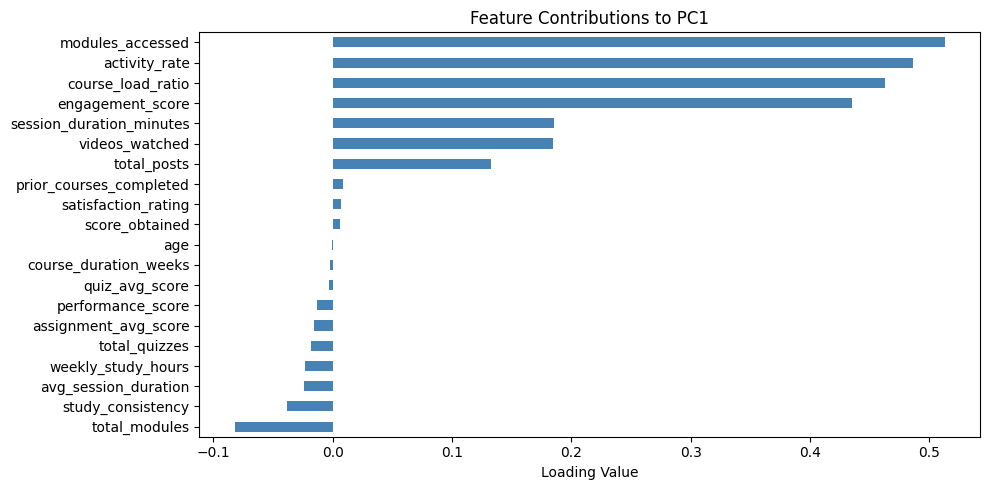

In [ ]:
plt.figure(figsize=(10,5))
loadings['PC1'].sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Contributions to PC1')
plt.xlabel('Loading Value')
plt.tight_layout()
plt.show()

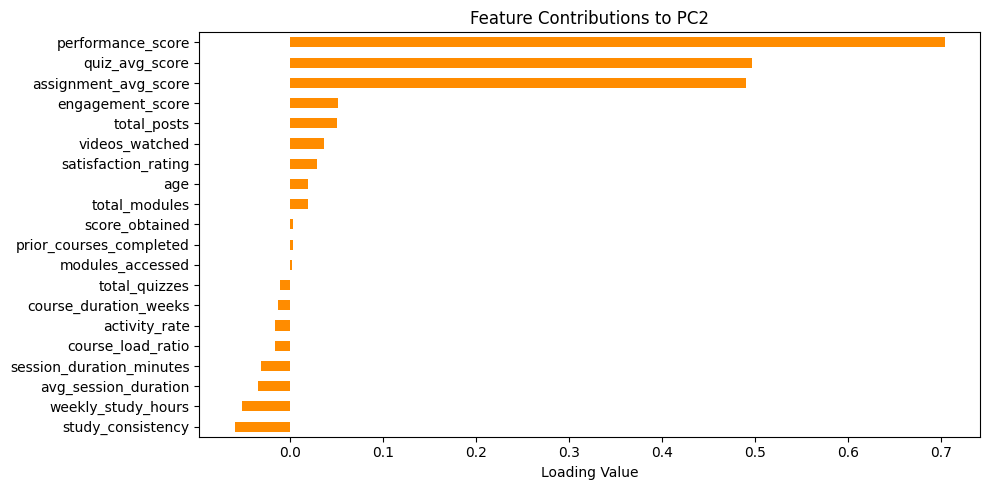

In [ ]:
plt.figure(figsize=(10,5))
loadings['PC2'].sort_values().plot(kind='barh', color='darkorange')
plt.title('Feature Contributions to PC2')
plt.xlabel('Loading Value')
plt.tight_layout()
plt.show()

# Discussion Questions:

Which features have the highest influence on PC1 and PC2?

How much total variance is captured and is PCA useful for this dataset?

How do the engineered features rank compared to the original features in terms of contribution?

### Discussion Questions - Answers:

1.  **Which features have the highest influence on PC1 and PC2?**

    Based on the feature loadings and the bar plots:
    *   **PC1** is most strongly influenced by: `modules_accessed` (0.51), `activity_rate` (0.49), `course_load_ratio` (0.46), and `engagement_score` (0.44). This component primarily captures aspects of **student engagement and activity** within the course.
    *   **PC2** is most strongly influenced by: `performance_score` (0.70), `quiz_avg_score` (0.50), and `assignment_avg_score` (0.49). This component primarily represents **academic performance**.

2.  **How much total variance is captured and is PCA useful for this dataset?**

    The two principal components (PC1 and PC2) together capture a total of **23.61%** of the total variance in the dataset. While PCA can be useful for visualization or reducing dimensionality when a significant portion of variance is captured, in this specific case, capturing less than 25% of the total variance with 2 components suggests that PCA might **not be highly useful** for a drastic dimensionality reduction while retaining most of the information. For classification tasks, using only these two components would mean losing a substantial amount of information from the original feature set, which could impact model performance.

3.  **How do the engineered features rank compared to the original features in terms of contribution?**

    The engineered features show a very strong influence on both PC1 and PC2:
    *   **PC1**: Three of the top four most influential features (`activity_rate`, `course_load_ratio`, `engagement_score`) are engineered features. This indicates that our engineered features related to engagement and course activity are highly effective in defining the first principal component.
    *   **PC2**: The `performance_score` is the most dominant feature for PC2 (0.70 loading), significantly outranking all original score-related features (`quiz_avg_score`, `assignment_avg_score`). This shows that our aggregated `performance_score` is a very strong and concise representation of academic performance.

    Overall, the engineered features demonstrate **stronger and more direct contributions** to the principal components compared to many of the original raw features, suggesting they are capturing the underlying variance more effectively.

# **Step 16: Reflection**

# Discussion Questions:

What was the most difficult data quality issue to detect in this dataset and why?

Which cleaning decision required the most judgment and how did the project context influence it?

If the inconsistencies in completion_status had not been fixed, how would this have affected the classification model?

How did the engineered features improve the PCA results?

What one additional feature would you propose to strengthen prediction of student course completion?

### Discussion Questions - Answers:

1.  **What was the most difficult data quality issue to detect in this dataset and why?**

    The most difficult data quality issue to detect was the **inconsistencies within the `completion_status` target variable**. Initially, `df.describe(include='object')` showed 10 unique values, which was immediately suspicious given the project's goal of predicting 'Complete', 'Drop', or 'Ongoing'. However, the *root cause* of these inconsistencies (e.g., 'Completed - No Certificate', 'In-progress', varying capitalization) required careful manual inspection and mapping, as they weren't simple missing values or obvious outliers in a numerical sense. It directly impacted the core prediction target and required a precise, domain-informed cleaning strategy.

2.  **Which cleaning decision required the most judgment and how did the project context influence it?**

    The cleaning decision that required the most judgment was **handling the numerous negative values and extreme outliers in numerical columns** (e.g., `age`, `weekly_study_hours`, `score_obtained`, etc.). The project context, an "Online Learning Prediction System," heavily influenced the decision to use Winsorization over deletion. Deleting rows with outliers, while simpler, would have resulted in significant data loss across many features. Given that each row represents a student and their learning journey, retaining as much data as possible was crucial to ensure the model had a comprehensive view of student behavior, even if some values were initially faulty. Winsorization allowed us to mitigate the impact of these extreme values without sacrificing valuable student records.

3.  **If the inconsistencies in `completion_status` had not been fixed, how would this have affected the classification model?**

    If the inconsistencies in `completion_status` had not been fixed, the classification model would have been severely compromised. It would have attempted to predict between 10 different, often semantically overlapping, classes instead of the intended three. This would lead to:
    *   **Reduced Model Performance**: The model would struggle to learn meaningful patterns, resulting in very low prediction accuracy and a high number of misclassifications.
    *   **Misleading Evaluation Metrics**: Metrics would be difficult to interpret, as the 'correct' labels themselves would be inconsistent.
    *   **Increased Complexity**: The model would be unnecessarily complex, trying to differentiate between 'Completed' and 'completed', for instance.
    *   **Unusable Model**: Ultimately, the model would be practically unusable for its intended purpose of identifying students who will 'Complete', 'Drop', or remain 'Ongoing'.

4.  **How did the engineered features improve the PCA results?**

    The engineered features significantly improved the PCA results by providing more meaningful and consolidated representations of student behavior. The feature loadings showed that:
    *   **PC1** was heavily influenced by engineered features like `activity_rate`, `course_load_ratio`, and `engagement_score`, indicating that these features better captured underlying dimensions of **student engagement** than individual raw metrics.
    *   **PC2** was strongly dominated by the `performance_score`, which is an engineered feature. This feature effectively summarized **academic performance**, providing a clear component for this aspect. By combining related raw features, the engineered features helped PCA find more interpretable and robust principal components that explained more focused aspects of the data's variance.

5.  **What one additional feature would you propose to strengthen prediction of student course completion?**

    I would propose an **`interactivity_score`** feature. This could be calculated as a combination of `total_posts` (already used in `engagement_score`) with a new hypothetical feature like `forum_response_rate` (if available) or `collaboration_project_contribution`. The `engagement_score` is general; an `interactivity_score` would specifically focus on how much a student interacts with peers or instructors beyond just consuming content. High interactivity often correlates with a stronger sense of community, increased motivation, and better learning outcomes, making it a strong potential predictor for course completion.

# **Step 17: Save Cleaned Dataset**
Task:
Save the fully cleaned and feature-engineered dataset to Google Drive for use in Notebook 2.

In [ ]:
output_path = '/content/drive/MyDrive/Online-Learning-Prediction/Datasets/Cleaned_OnlineLearning.csv'
df.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully.")
print(f"Path: {output_path}")
print(f"Final shape: {df.shape}")

Cleaned dataset saved successfully.
Path: /content/drive/MyDrive/Online-Learning-Prediction/Datasets/Cleaned_OnlineLearning.csv
Final shape: (7000, 35)


# Discussion Questions:

Why is it important to save the cleaned dataset separately rather than overwriting the original raw file?

How does saving to Google Drive support collaboration among group members?

What would be the consequence for Notebook 2 if this file were saved with remaining data quality issues?

### Discussion Questions - Answers:

1.  **Why is it important to save the cleaned dataset separately rather than overwriting the original raw file?**

    It is crucial to save the cleaned dataset separately for several reasons:
    *   **Reproducibility**: It allows for full reproducibility. If any cleaning steps need to be re-evaluated or changed, the original raw data is preserved and can be re-accessed at any time.
    *   **Auditing and Traceability**: It provides a clear audit trail of the data transformation process. We can compare the raw and cleaned versions to understand the impact of each cleaning step.
    *   **Integrity of Original Data**: Prevents accidental alteration or corruption of the source data, ensuring that the original data source remains untouched.
    *   **Debugging**: If issues arise in downstream processes (e.g., during model training in Notebook 2), having the raw data available simplifies debugging and pinpointing where the error might have been introduced.

2.  **How does saving to Google Drive support collaboration among group members?**

    Saving the cleaned dataset to Google Drive significantly enhances collaboration among group members by:
    *   **Centralized Access**: All team members have instant access to the latest version of the cleaned dataset from any location, eliminating the need for manual file transfers.
    *   **Version Control (Implicit)**: While not a full version control system like Git, Google Drive often keeps revision history, allowing team members to revert to previous versions if needed.
    *   **Shared Workspace**: It creates a common workspace where subsequent notebooks (like Notebook 2 for modeling) can seamlessly load the prepared data without local setup complexities.
    *   **Efficiency**: Reduces overhead and potential errors associated with disparate local copies of the data.

3.  **What would be the consequence for Notebook 2 if this file were saved with remaining data quality issues?**

    If the cleaned dataset were saved with remaining data quality issues and then used in Notebook 2 (for modeling), the consequences would be severe:
    *   **Flawed Model Training**: The machine learning model would be trained on unreliable, inaccurate, or biased data, leading to a model that learns incorrect patterns.
    *   **Poor Model Performance**: The model would likely exhibit low accuracy, precision, recall, or F1-score in real-world scenarios, as its predictions would be based on faulty inputs.
    *   **Misleading Evaluation**: Any evaluation metrics reported in Notebook 2 would be optimistically skewed or simply incorrect, giving a false sense of the model's effectiveness.
    *   **Incorrect Business Decisions**: If deployed, such a model could lead to erroneous predictions (e.g., misidentifying at-risk students), resulting in ineffective or even detrimental interventions and decisions.
    *   **Wasted Effort**: The entire effort of building and training a model would be compromised, as the foundational data is unsound.